# Statistical Hypothesis Testing Guide

This notebook demonstrates how to use the custom `numstats.hypothesis_testing` module to perform parametric and non-parametric hypothesis tests. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from numstats.hypothesis_testing import (
    one_sample_mean_test,
    independent_means_test,
    paired_means_test,
    variance_test,
    uniform_goodness_of_fit,
    poisson_goodness_of_fit
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

---
## 1. One-Sample Mean Test ($Z$-test / $t$-test)
**Scenario:** A delivery company claims their average delivery time is 30 minutes ($H_0: \mu = 30$). We collect a small sample of 10 deliveries to verify if the real time is **greater** than claimed ($H_A: \mu > 30$).

In [2]:
delivery_times = [31.2, 29.5, 35.0, 33.4, 28.9, 32.1, 34.5, 30.0, 31.8, 36.2]

stat, accept_h0 = one_sample_mean_test(
    sample=delivery_times, hypothesized_mean=30.0, std_dev=None, alpha=0.05, alternative="greater"
)
print(f"Test Statistic: {stat:.4f} | Fail to reject H0: {accept_h0}")

Test Statistic: 2.8983 | Fail to reject H0: False


---
## 2. Independent Two-Sample Means Test
**Scenario:** A tech team wants to check if Website Layout A generates more clicks than Layout B. They run an A/B test on two independent user groups.

In [3]:
clicks_layout_a = [12, 15, 14, 11, 19, 13, 16, 14, 12, 15]
clicks_layout_b = [10, 11, 13, 9, 12, 14, 10, 11, 13, 11]

stat, accept_h0 = independent_means_test(
    clicks_layout_a, clicks_layout_b, alpha=0.05, alternative="two-sided"
)
print(f"Test Statistic: {stat:.4f} | Fail to reject H0 (Layouts are equal): {accept_h0}")

Test Statistic: 3.0335 | Fail to reject H0 (Layouts are equal): False


---
## 3. Paired Samples Mean Test (Dependent Variables)
**Scenario:** A fitness center evaluates a 4-week weight loss program. They measure the weight of 5 participants **before** and **after** the program.

In [4]:
weight_before = [95.5, 88.0, 104.2, 79.8, 92.1]
weight_after  = [93.0, 86.2, 101.5, 80.0, 89.9]  # General weight loss observed

stat, accept_h0 = paired_means_test(
    weight_before, weight_after, hypothesized_difference=0.0, alpha=0.05, alternative="greater"
)
print(f"Test Statistic: {stat:.4f} | Fail to reject H0 (No weight loss): {accept_h0}")

Test Statistic: 3.4450 | Fail to reject H0 (No weight loss): False


---
## 4. Chi-Square Variance Test
**Scenario:** A manufacturing company limits a component's length variance to 0.02 mm² ($H_0: \sigma^2 \le 0.02$). We test a batch to ensure the machine isn't introducing too much product instability.

In [5]:
component_lengths = [10.1, 10.3, 9.9, 10.2, 10.0, 10.4, 9.8, 10.1, 10.2, 10.0]

stat, accept_h0 = variance_test(
    component_lengths, hypothesized_variance=0.02, alpha=0.05, alternative="greater"
)
print(f"Test Statistic: {stat:.4f} | Fail to reject H0 (Variance within limits): {accept_h0}")

Test Statistic: 15.0000 | Fail to reject H0 (Variance within limits): True


---
## 5. Chi-Square Goodness-of-Fit (Uniform & Poisson)
**Scenario 1 (Uniform):** Testing a six-sided die to confirm it is fair (all outcomes should have equal frequencies).
**Scenario 2 (Poisson):** Testing if hourly customer arrivals follow a Poisson distribution with $\lambda = 2$.

In [7]:
# 1. Uniform Test (60 rolls of a die, expected 10 for each face)
die_rolls = [11, 9, 12, 8, 10, 10]
_, fair_die = uniform_goodness_of_fit(die_rolls, alpha=0.05)
print(f"Is the die fair (Uniform)? {fair_die}")

# 2. Poisson Test (Observed hours with 0, 1, 2, 3+ customer arrivals)
traffic_data = [15, 28, 30, 27]  
_, fits_poisson = poisson_goodness_of_fit(traffic_data, lam=2.0, alpha=0.05)
print(f"Does traffic fit Poisson distribution? {fits_poisson}")

Is the die fair (Uniform)? True
Does traffic fit Poisson distribution? True


---
## 6. Visualization: Understanding the Rejection Region
Below is a standard representation of a two-sided test at $\alpha = 0.05$. If our calculated test statistic falls into the red shaded area, we reject the null hypothesis ($H_0$).

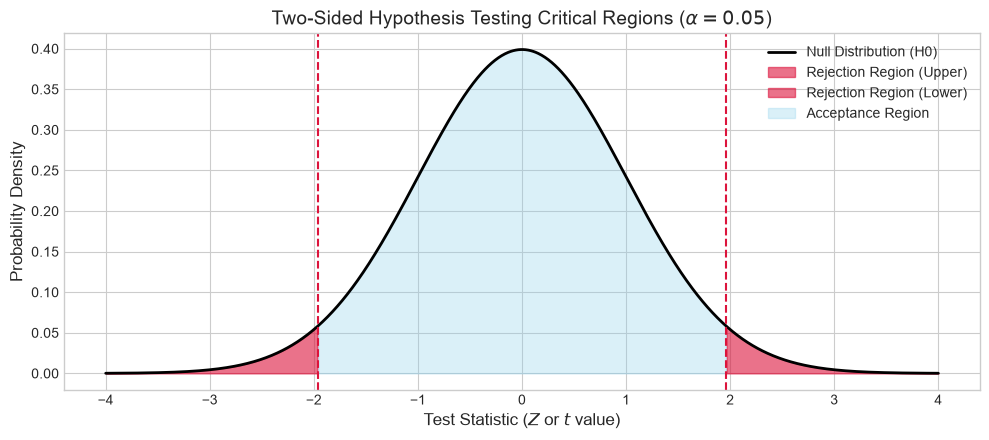

In [8]:
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)
z_crit = norm.ppf(0.975)

plt.figure(figsize=(10, 4.5))
plt.plot(x, y, color='black', linewidth=2, label='Null Distribution (H0)')

# Shading rejection regions
plt.fill_between(x, y, where=(x >= z_crit), color='crimson', alpha=0.6, label='Rejection Region (Upper)')
plt.fill_between(x, y, where=(x <= -z_crit), color='crimson', alpha=0.6, label='Rejection Region (Lower)')
plt.fill_between(x, y, where=(x > -z_crit) & (x < z_crit), color='skyblue', alpha=0.3, label='Acceptance Region')

plt.axvline(z_crit, color='crimson', linestyle='--', linewidth=1.5)
plt.axvline(-z_crit, color='crimson', linestyle='--', linewidth=1.5)

plt.title('Two-Sided Hypothesis Testing Critical Regions ($\\alpha = 0.05$)', fontsize=14)
plt.xlabel('Test Statistic ($Z$ or $t$ value)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()